# Violence Detection

## Attempt 1 - MoBiLSTM

In [3]:
import os
import shutil
import cv2
import math
import random
import numpy as np
import datetime as dt
import tensorflow 
import keras
from collections import deque
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
 
from keras.layers import *
from keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

In [27]:
import tensorflow as tf

In [ ]:
# Classes Directories
NonViolenceVideos_Dir = r"datasets\SCVD\SCVD_converted_sec_list\Train\Normal"
ViolenceVideos_Dir = r"datasets\SCVD\SCVD_converted_sec_list\Train\Violence"

# Retrieve the list of all the video files present in the Class Directory.
NonViolence_files_names_list = os.listdir(NonViolenceVideos_Dir)
Violence_files_names_list = os.listdir(ViolenceVideos_Dir)

In [ ]:
# Specify the height and width to which each video frame will be resized in our dataset.
IMAGE_HEIGHT , IMAGE_WIDTH = 64, 64
 
# Specify the number of frames of a video that will be fed to the model as one sequence.
SEQUENCE_LENGTH = 16
 

DATASET_DIR = "datasets\SCVD\SCVD_converted_sec_list\Train"
 
CLASSES_LIST = ["Normal","Violence"]

In [14]:
def frames_extraction(video_path):
 
    frames_list = []
    
    # Read the Video File
    video_reader = cv2.VideoCapture(video_path)
 
    # Get the total number of frames in the video.
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
 
    # Calculate the the interval after which frames will be added to the list.
    skip_frames_window = max(int(video_frames_count/SEQUENCE_LENGTH), 1)
 
    # Iterate through the Video Frames.
    for frame_counter in range(SEQUENCE_LENGTH):
 
        # Set the current frame position of the video.
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)
 
        # Reading the frame from the video. 
        success, frame = video_reader.read() 
 
        if not success:
            break
 
        # Resize the Frame to fixed height and width.
        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))
        
        # Normalize the resized frame
        normalized_frame = resized_frame / 255
        
        # Append the normalized frame into the frames list
        frames_list.append(normalized_frame)
    
 
    video_reader.release()
 
    return frames_list

In [15]:
def create_dataset():
 
    features = []
    labels = []
    video_files_paths = []
    
    # Iterating through all the classes.
    for class_index, class_name in enumerate(CLASSES_LIST):
        
        print(f'Extracting Data of Class: {class_name}')
        
        # Get the list of video files present in the specific class name directory.
        files_list = os.listdir(os.path.join(DATASET_DIR, class_name))
        
        # Iterate through all the files present in the files list.
        for file_name in files_list:
            
            # Get the complete video path.
            video_file_path = os.path.join(DATASET_DIR, class_name, file_name)
 
            # Extract the frames of the video file.
            frames = frames_extraction(video_file_path)
 
            # Check if the extracted frames are equal to the SEQUENCE_LENGTH specified.
            # So ignore the vides having frames less than the SEQUENCE_LENGTH.
            if len(frames) == SEQUENCE_LENGTH:
 
                # Append the data to their repective lists.
                features.append(frames)
                labels.append(class_index)
                video_files_paths.append(video_file_path)
 
    features = np.asarray(features)
    labels = np.array(labels)  

    return features, labels, video_files_paths

In [18]:
# Create the dataset.
features, labels, video_files_paths = create_dataset()

Extracting Data of Class: Normal
Extracting Data of Class: Violence


In [19]:
# Saving the extracted data
np.save("features.npy",features)
np.save("labels.npy",labels)
np.save("video_files_paths.npy",video_files_paths)

In [20]:
features, labels, video_files_paths = np.load("features.npy") , np.load("labels.npy") ,  np.load("video_files_paths.npy")

In [21]:
# convert labels into one-hot-encoded vectors
one_hot_encoded_labels = to_categorical(labels)

In [22]:
# Split the Data into Train ( 90% ) and Test Set ( 10% ).
features_train, features_test, labels_train, labels_test = train_test_split(features, one_hot_encoded_labels, test_size = 0.1,
                                                                            shuffle = True, random_state = 42)

In [23]:
from keras.applications.mobilenet_v2 import MobileNetV2

mobilenet = MobileNetV2( include_top=False , weights="imagenet")

#train last 40 layers
mobilenet.trainable= True
for layer in mobilenet.layers[:-40]:
  layer.trainable=False

C:\Users\Jun\AppData\Local\Temp\ipykernel_8396\2612116336.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2( include_top=False , weights="imagenet")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [24]:
def create_model():
 
    model = Sequential()

    ########################################################################################################################
    
    #Specifying Input to match features shape
    model.add(Input(shape = (SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))
    
    # Passing mobilenet in the TimeDistributed layer to handle the sequence
    model.add(TimeDistributed(mobilenet))
    
    model.add(Dropout(0.25))
                                    
    model.add(TimeDistributed(Flatten()))

    
    lstm_fw = LSTM(units=32)
    lstm_bw = LSTM(units=32, go_backwards = True)  

    model.add(Bidirectional(lstm_fw, backward_layer = lstm_bw))
    
    model.add(Dropout(0.25))

    model.add(Dense(256,activation='relu'))
    model.add(Dropout(0.25))

    model.add(Dense(128,activation='relu'))
    model.add(Dropout(0.25))

    model.add(Dense(64,activation='relu'))
    model.add(Dropout(0.25))

    model.add(Dense(32,activation='relu'))
    model.add(Dropout(0.25))
    
    
    model.add(Dense(len(CLASSES_LIST), activation = 'softmax'))
  
    model.summary()
    
    return model

In [25]:
# Constructing the Model
MoBiLSTM_model = create_model()

# Plot the structure of the contructed LRCN model.
plot_model(MoBiLSTM_model, to_file = 'MobBiLSTM_model_structure_plot.png', show_shapes = True, show_layer_names = True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 16, 2, 2, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 2, 2, 1280) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 16, 5120)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │     1,319,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,637,090 (13.87 MB)

 Trainable params: 3,060,642 (11.68 MB)

 Non-trainable params: 576,448 (2.20 MB)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [28]:
# Create Early Stopping Callback to monitor the accuracy
early_stopping_callback = EarlyStopping(monitor = 'val_accuracy', patience = 10, restore_best_weights = True)

# Create ReduceLROnPlateau Callback to reduce overfitting by decreasing learning
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                  factor=0.6,
                                                  patience=5,
                                                  min_lr=0.00005,
                                                  verbose=1)
 
# Compiling the model 
MoBiLSTM_model.compile(loss = 'categorical_crossentropy', optimizer = 'sgd', metrics = ["accuracy"])
 
# Fitting the model 
MobBiLSTM_model_history = MoBiLSTM_model.fit(x = features_train, y = labels_train, epochs = 50, batch_size = 8 ,
                                             shuffle = True, validation_split = 0.2, callbacks = [early_stopping_callback,reduce_lr])

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 65s 619ms/step - accuracy: 0.6279 - loss: 0.6654 - val_accuracy: 0.6852 - val_loss: 0.6543 - learning_rate: 0.0100
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 264ms/step - accuracy: 0.6465 - loss: 0.6527 - val_accuracy: 0.7222 - val_loss: 0.6039 - learning_rate: 0.0100
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 260ms/step - accuracy: 0.6558 - loss: 0.6494 - val_accuracy: 0.7222 - val_loss: 0.6192 - learning_rate: 0.0100
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 272ms/step - accuracy: 0.6326 - loss: 0.6531 - val_accuracy: 0.7222 - val_loss: 0.6148 - learning_rate: 0.0100
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 261ms/step - accuracy: 0.6279 - loss: 0.6371 - val_accuracy: 0.7222 - val_loss: 0.5994 - learning_rate: 0.0100
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 257ms/step - accuracy: 0.6465 - loss: 0.6325 - val_accuracy: 0.7222 - val_loss: 0.5819 - learning_rate: 0.0100
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 264ms/step - accuracy: 0.6419 - loss: 0.6235 -

In [29]:
model_evaluation_history = MoBiLSTM_model.evaluate(features_test, labels_test)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.7333 - loss: 0.4613


In [ ]:
labels_predict = MoBiLSTM_model.predict(features_test)

In [31]:
def plot_metric(model_training_history, metric_name_1, metric_name_2, plot_name):
    
    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]
    
    # Get the Epochs Count
    epochs = range(len(metric_value_1))
 
    plt.plot(epochs, metric_value_1, 'blue', label = metric_name_1)
    plt.plot(epochs, metric_value_2, 'orange', label = metric_name_2)
 
    plt.title(str(plot_name))
 
    plt.legend()

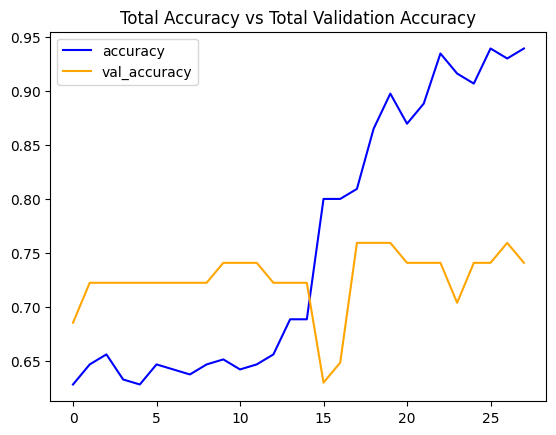

In [32]:


plot_metric(MobBiLSTM_model_history, 'accuracy', 'val_accuracy', 'Total Accuracy vs Total Validation Accuracy')



## Attempt 2 - ConvLSTM

In [35]:
# Alternative architecture: ConvLSTM model for spatiotemporal violence detection
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

def create_convlstm_model():
    model = Sequential()

    model.add(Input(shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))

    model.add(ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        activation='tanh',
        return_sequences=True,
        recurrent_dropout=0.2
    ))
    model.add(BatchNormalization())

    model.add(ConvLSTM2D(
        filters=64,
        kernel_size=(3, 3),
        padding='same',
        activation='tanh',
        return_sequences=False,
        recurrent_dropout=0.2
    ))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling2D())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(len(CLASSES_LIST), activation='softmax'))

    model.summary()
    return model


In [36]:
# Construct and visualize the ConvLSTM model
ConvLSTM_model = create_convlstm_model()
plot_model(ConvLSTM_model, to_file='ConvLSTM_model_structure_plot.png', show_shapes=True, show_layer_names=True)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 16, 64, 64, 32) │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 64, 64, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 64, 64, 64)     │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 270,850 (1.03 MB)

 Trainable params: 270,658 (1.03 MB)

 Non-trainable params: 192 (768.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [38]:
# Train the ConvLSTM model using the same inputs as MoBiLSTM
early_stopping_convlstm = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
reduce_lr_convlstm = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=1)

ConvLSTM_model.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

ConvLSTM_model_history = ConvLSTM_model.fit(
    x=features_train,
    y=labels_train,
    epochs=50,
    batch_size=8,
    shuffle=True,
    validation_split=0.2,
    callbacks=[early_stopping_convlstm, reduce_lr_convlstm]
)


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.6465 - loss: 0.6502 - val_accuracy: 0.7222 - val_loss: 0.6359 - learning_rate: 1.0000e-04
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.6326 - loss: 0.6391 - val_accuracy: 0.7222 - val_loss: 0.6390 - learning_rate: 1.0000e-04
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.7023 - loss: 0.6075 - val_accuracy: 0.7222 - val_loss: 0.6119 - learning_rate: 1.0000e-04
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.7070 - loss: 0.5864 - val_accuracy: 0.7222 - val_loss: 0.6098 - learning_rate: 1.0000e-04
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.7163 - loss: 0.5865 - val_accuracy: 0.7222 - val_loss: 0.6139 - learning_rate: 1.0000e-04
Epoch 6/50
 1/27 ━━━━━━━━━━━━━━━━━━━━ 1:05 3s/step - accuracy: 0.7500 - loss: 0.5224

KeyboardInterrupt: 

In [ ]:
# Evaluate on the same held-out test set
convlstm_test_loss, convlstm_test_accuracy = ConvLSTM_model.evaluate(features_test, labels_test, verbose=1)
print(f'ConvLSTM test loss: {convlstm_test_loss:.4f}')
print(f'ConvLSTM test accuracy: {convlstm_test_accuracy:.4f}')


In [ ]:
# Plot training curves for the alternative model
plt.figure(figsize=(8, 4))
plt.plot(ConvLSTM_model_history.history['accuracy'], label='train_accuracy')
plt.plot(ConvLSTM_model_history.history['val_accuracy'], label='val_accuracy')
plt.title('ConvLSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## Atmept 3 - MobileNetV2

In [43]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.applications import MobileNetV2,Xception,EfficientNetB7,InceptionResNetV2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input,LSTM, ConvLSTM2D, MaxPooling3D, TimeDistributed, Dense, Flatten, Dropout, Bidirectional, MaxPooling2D, InputLayer, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback

from IPython.display import clear_output,Video

import os
import json
import cv2

In [39]:
scvd_train_dir = r"datasets\SCVD\SCVD_converted_sec_split\Train"
scvd_test_dir = r"datasets\SCVD\SCVD_converted_sec_split\Test"
scvd_classes = ['Normal', 'Violence','Weaponized']


In [40]:
IMG_SIZE = 128
FRAME_COUNT = 15

def load_video(path, nframes=FRAME_COUNT, size=(IMG_SIZE, IMG_SIZE)):
    frames = []
    cap = cv2.VideoCapture(path)

    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) # Get the total number of frames in the video
    skip_frames = max(1, (total_frames // nframes) -1)  # Ensure at least 1 frame is skipped

    for _ in range(nframes):
        ret, frame = cap.read()  # Read the current frame
        if not ret:
            break

        # Process the current frame (resize, convert, normalize)
        frame = cv2.resize(frame, size)
        frame = frame[:, :, [2, 1, 0]]  # BGR to RGB
        frame = frame / 255.0
        frames.append(frame)

        # Skip the specified number of frames
        for _ in range(skip_frames):
            cap.grab()  # Advance to the next frame without reading it

    cap.release() 
    return frames


def extract_frames(main_directory):
    features = []
    labels = []
    for c in scvd_classes:
        class_dir = os.path.join(main_directory,c)
        for i,video in enumerate(os.listdir(class_dir)): 
            if i < 650:
                if video.endswith(('.mp4', '.avi', '.mov')): 
                    video_path = os.path.join(class_dir, video)

                    # Load and process the video
                    frames = load_video(video_path)

                    if len(frames) == FRAME_COUNT:
                        features.append(frames)
                        labels.append(c)
    return np.asarray(features),np.array(labels)

In [41]:
X_train,y_train = extract_frames(scvd_train_dir)
X_test,y_test = extract_frames(scvd_test_dir)

y_train = np.where(y_train == 'Weaponized','Violence',y_train)

y_test = np.where(y_test == 'Weaponized','Violence',y_test)

In [44]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [51]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))


for layer in base_model.layers:
    layer.trainable = False


model = Sequential()
model.add(TimeDistributed(base_model, input_shape=(15, 128, 128, 3)))
model.add(TimeDistributed(GlobalAveragePooling2D())) 
model.add(TimeDistributed(Dropout(0.5)))
model.add(TimeDistributed(BatchNormalization()))

model.add(LSTM(128, return_sequences=True))
model.add(LSTM(64, return_sequences=False))

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))  

model.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_6              │ (None, 15, 4, 4, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 15, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 15, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 15, 1280)       │         5,120 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 15, 128)        │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,093,313 (11.80 MB)

 Trainable params: 832,001 (3.17 MB)

 Non-trainable params: 2,261,312 (8.63 MB)

In [57]:
early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history = model.fit(
    x=X_train,
    y= y_train,
    validation_split=0.2,
    callbacks=[early_stopping],
    epochs= 30,
)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.9737 - loss: 0.0884 - val_accuracy: 0.8846 - val_loss: 0.2622
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.9673 - loss: 0.0861 - val_accuracy: 0.8949 - val_loss: 0.2498
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.9852 - loss: 0.0421 - val_accuracy: 0.8333 - val_loss: 0.3533
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.9897 - loss: 0.0338 - val_accuracy: 0.7897 - val_loss: 0.5473
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.9929 - loss: 0.0216 - val_accuracy: 0.8692 - val_loss: 0.4553
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.9942 - loss: 0.0185 - val_accuracy: 0.8538 - val_loss: 0.6397
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.9936 - loss: 0.0218 - val_accuracy: 0.8128 - val_loss: 0.8042
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.9923 - loss: 0.0273 - val_accuracy: 0.8154 - v

In [59]:
model.save("models/violence_MobileNet.keras")

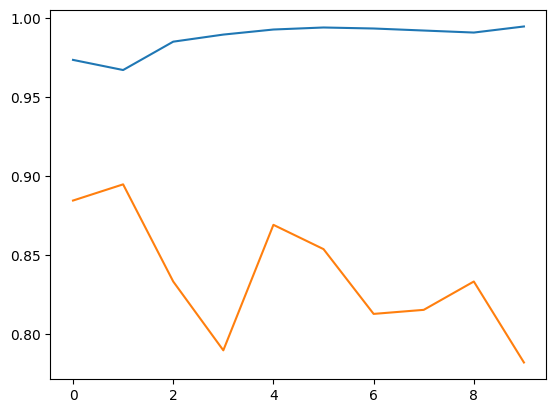

In [58]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

# Fire / Smoke  Detection

In [60]:
from ultralytics import YOLO
model = YOLO("yolo11n.pt")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Jun\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [62]:
import os, cv2, yaml, random, numpy as np
from PIL import Image
from glob import glob
from matplotlib import pyplot as plt
from torchvision import transforms as T

In [76]:
# Load YAML content into a Python dictionary
yml_file_path = r"datasets/fire/data.yaml"

with open(yml_file_path, 'r') as file: data = yaml.safe_load(file)

# Update the paths
data['train'] = r'datasets/fire/data/train'
data['val']   = r'datasets/fire/data/val'
data['test']  = r'datasets/fire/data/test'

In [77]:
output_path = r'fire-config.yaml'
with open(output_path, 'w') as file: yaml.dump(data, file, default_flow_style=False)

In [78]:
train_results = model.train(    
    data=output_path,
    epochs=30,  # number of training epochs
    imgsz=480,  # training image size
    )  # device to run on, i.e. device=0 or device=0,1,2,3 or device=cpu

Ultralytics 8.4.19  Python-3.10.4 torch-2.10.0+cpu CPU (AMD Ryzen 5 5600 6-Core Processor)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=fire-config.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

KeyboardInterrupt: 

In [79]:
torch.save(model, 'fire_yolov11.pt')

NameError: name 'torch' is not defined